In [43]:
import torch
print(torch.cuda.is_available())        # Должно быть True
print(torch.cuda.get_device_name(0))    # Название твоей карты

True
AMD Radeon RX 9070


In [44]:
import os
import glob
import cv2
import numpy as np
from collections import defaultdict
from ultralytics import YOLO
from tqdm.notebook import tqdm  # прогресс-бар для ноутбука
from IPython.display import clear_output, display, Video
import PIL.Image

# Проверка GPU (для информации)
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


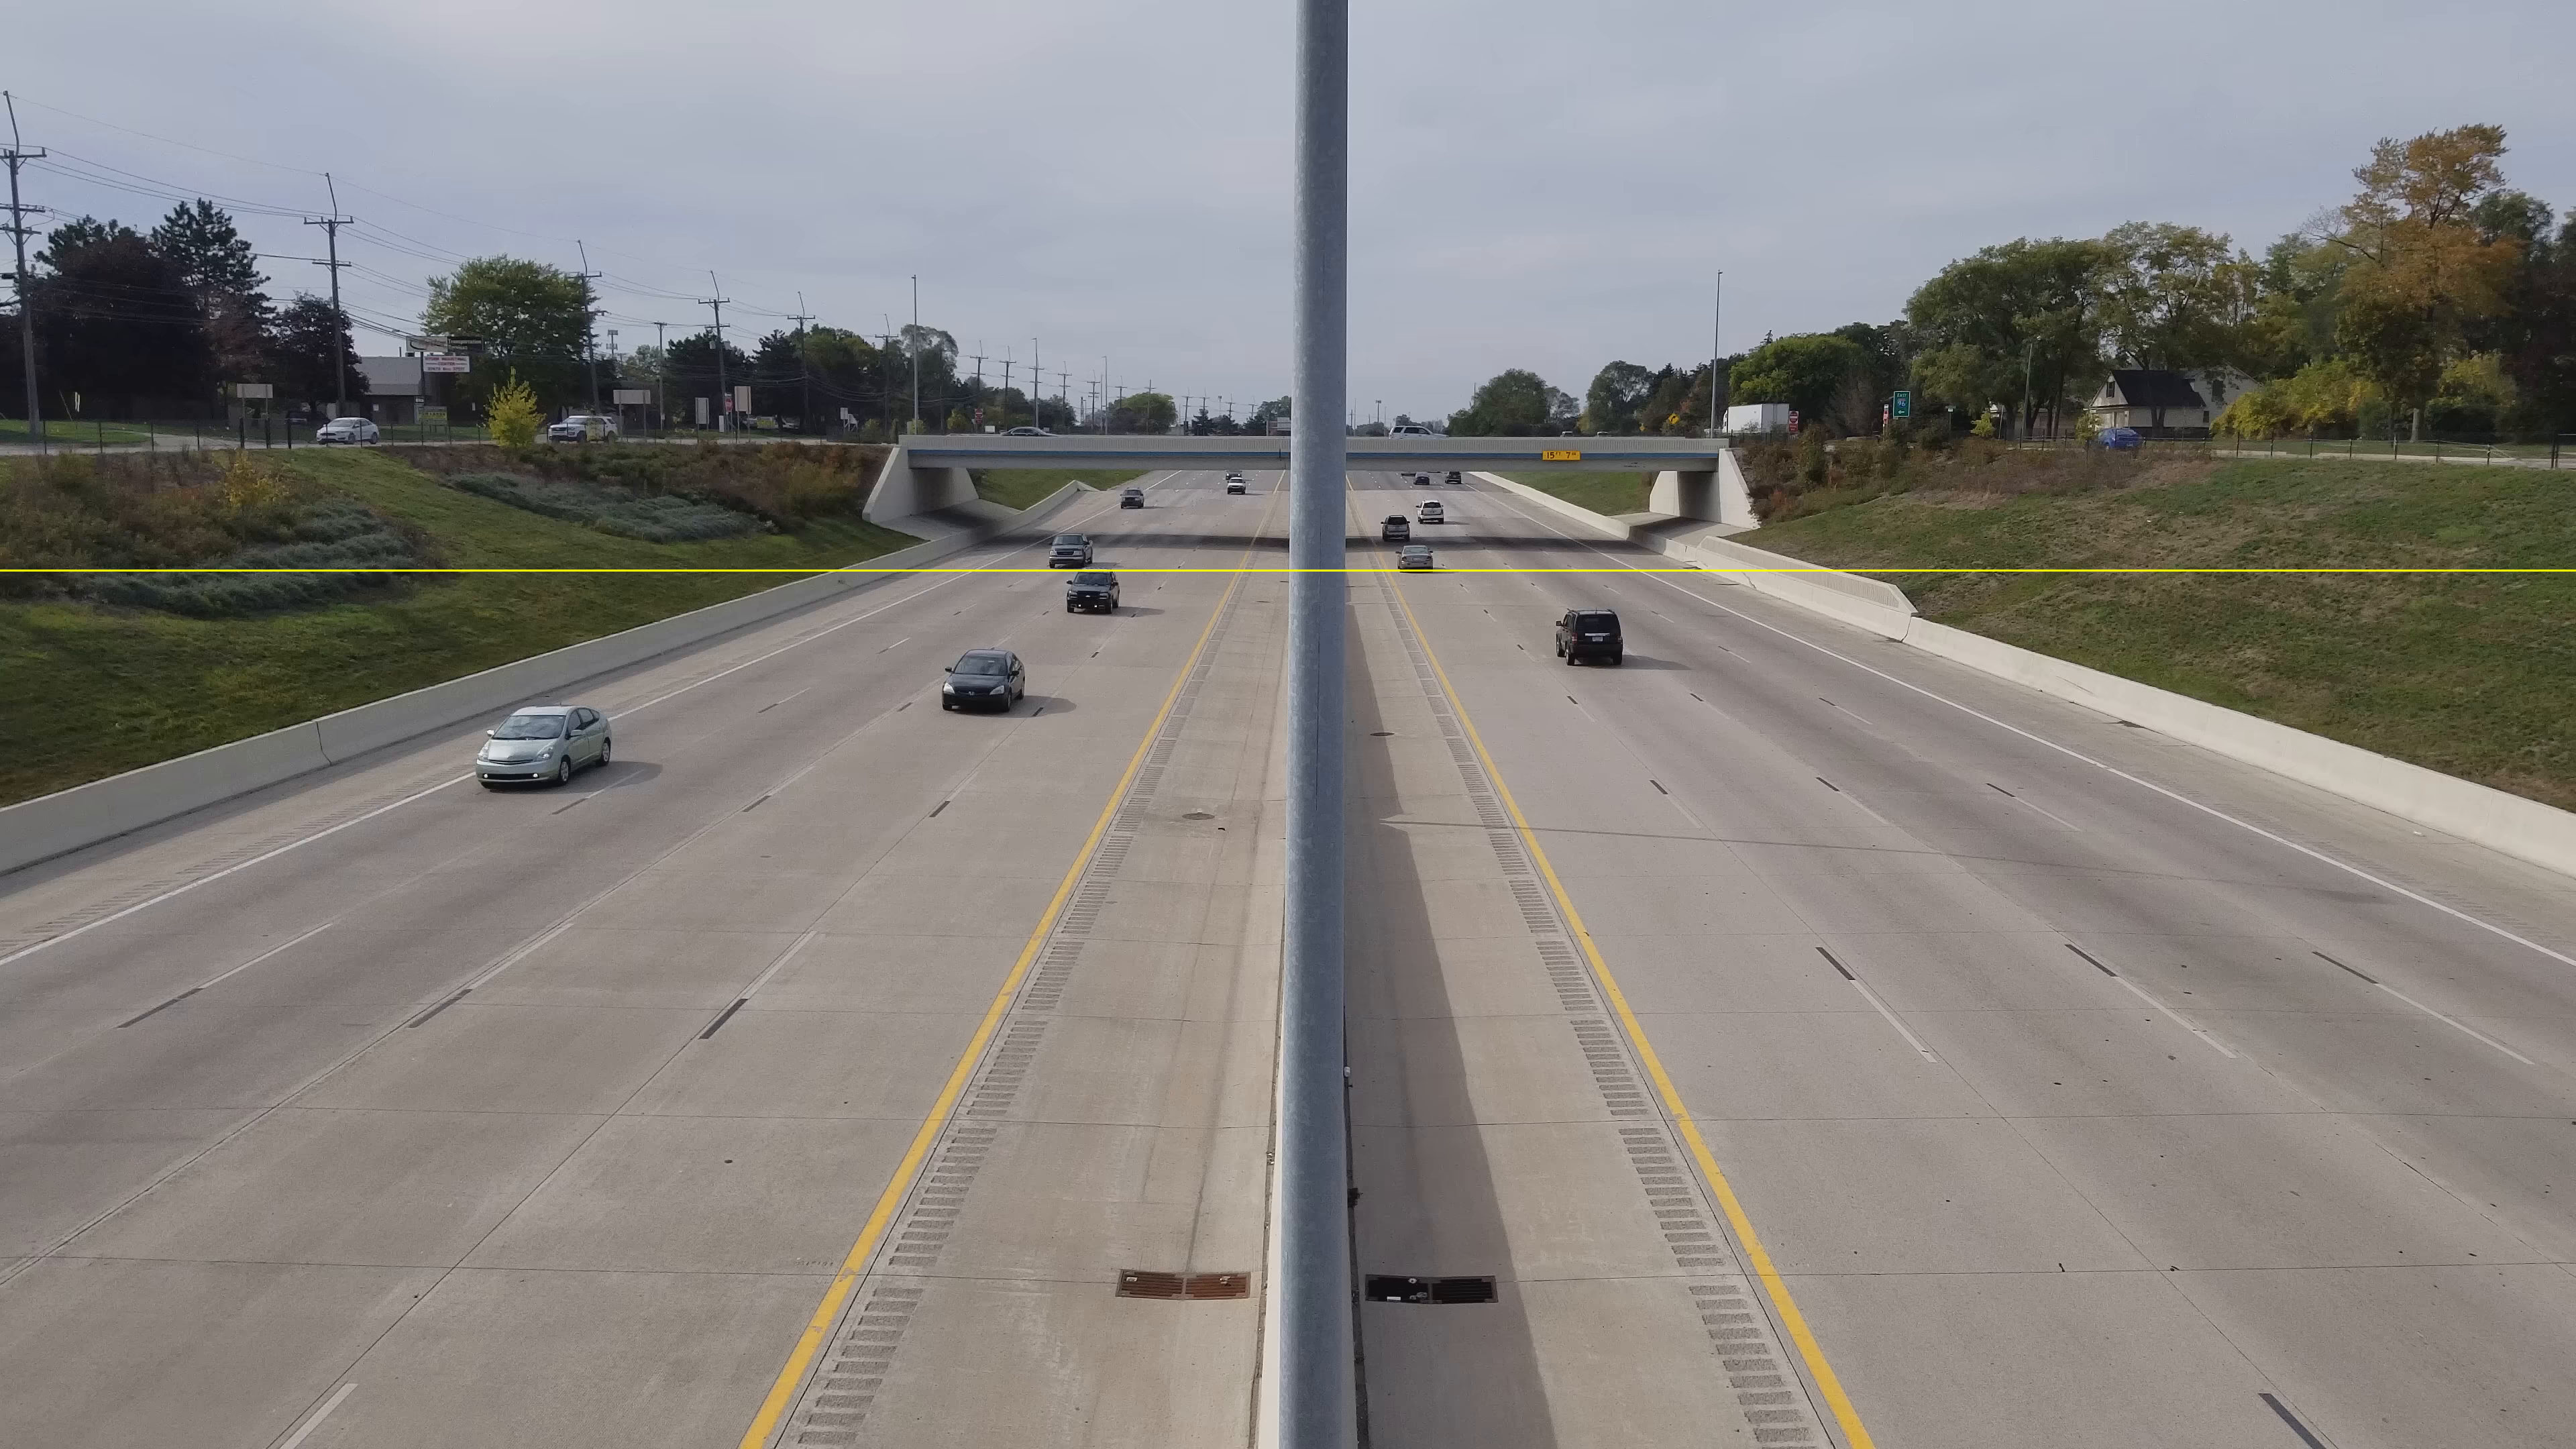

Линия отрисована. Проверьте, что она перекрывает обе полосы.


In [45]:
# === Настройки ===
VIDEO_DIR = "../data/video"
OUTPUT_VIDEO_DIR = "../output/video"
os.makedirs(OUTPUT_VIDEO_DIR, exist_ok=True)

# Линия подсчёта – твои координаты (горизонтальная поперёк дороги)
LINE_START = (0, 850)   # (x1, y1)
LINE_END   = (3850, 850)  # (x2, y2)

# Теперь мы считаем оба направления: "вверх" (приближение) и "вниз" (удаление)
# Никакого COUNT_DIRECTION не нужно – будем определять автоматически

CONF_THRESHOLD = 0.1
CLASS_ID = 2  # автомобиль в COCO

# Визуальная проверка линии на первом кадре (как раньше)
def get_first_video(directory):
    import glob
    video_exts = (".mp4", ".avi", ".mov", ".mkv", ".webm")
    files = sorted(glob.glob(os.path.join(directory, "*")))
    for f in files:
        name = os.path.basename(f)
        if name.startswith(".") or name == ".gitkeep":
            continue
        if any(f.lower().endswith(ext) for ext in video_exts):
            return f
    raise FileNotFoundError(f"Видео не найдено в {directory}")

try:
    test_video_path = get_first_video(VIDEO_DIR)
    cap_test = cv2.VideoCapture(test_video_path)
    ret, frame_test = cap_test.read()
    cap_test.release()
    if ret:
        frame_with_line = frame_test.copy()
        cv2.line(frame_with_line, LINE_START, LINE_END, (0, 255, 255), 2)
        rgb = cv2.cvtColor(frame_with_line, cv2.COLOR_BGR2RGB)
        display(PIL.Image.fromarray(rgb))
        print("Линия отрисована. Проверьте, что она перекрывает обе полосы.")
    else:
        print("Не удалось прочитать первый кадр.")
except Exception as e:
    print(f"Ошибка визуализации: {e}")

In [46]:
def get_center(box):
    x1, y1, x2, y2 = box
    return (int((x1 + x2) / 2), int((y1 + y2) / 2))

def line_side(point, line_start, line_end):
    x, y = point
    x1, y1 = line_start
    x2, y2 = line_end
    return (x2 - x1) * (y - y1) - (y2 - y1) * (x - x1)

def check_crossing(prev_center, curr_center, line_start, line_end):
    """
    Проверяет, было ли пересечение линии, и возвращает направление:
    'up' – если объект движется вверх (y уменьшается),
    'down' – если движется вниз (y увеличивается),
    None – если пересечения не было.
    """
    side_prev = line_side(prev_center, line_start, line_end)
    side_curr = line_side(curr_center, line_start, line_end)
    if side_prev == 0 or side_curr == 0:
        return None
    if side_prev * side_curr >= 0:  # знаки одинаковые – не пересекали
        return None
    # Пересечение есть – определяем направление по изменению y
    if curr_center[1] < prev_center[1]:
        return "up"
    else:
        return "down"

In [47]:
# Загружаем YOLOv8 (автоматически скачает в кеш ultralytics)
model = YOLO("../model/yolov8x.pt")

# Поиск видео
def get_first_video(directory):
    video_exts = (".mp4", ".avi", ".mov", ".mkv", ".webm")
    files = sorted(glob.glob(os.path.join(directory, "*")))
    for f in files:
        name = os.path.basename(f)
        if name.startswith(".") or name == ".gitkeep":
            continue
        if any(f.lower().endswith(ext) for ext in video_exts):
            return f
    raise FileNotFoundError(f"Видео не найдено в {directory}")

video_path = get_first_video(VIDEO_DIR)
print(f"Обрабатывается: {video_path}")

Обрабатывается: ../data/video/videoplayback.mp4


In [48]:
import sys
import time

cap = cv2.VideoCapture(video_path)
assert cap.isOpened(), "Не удалось открыть видео"

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

base_name = os.path.splitext(os.path.basename(video_path))[0]
output_video_path = os.path.join(OUTPUT_VIDEO_DIR, f"{base_name}_counted.mp4")
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

track_history = defaultdict(list)
crossed_ids = set()         # множество ID, которые уже пересекли линию (любое направление)
count_up = 0                # счётчик "на нас" (движение вверх)
count_down = 0              # счётчик "от нас" (движение вниз)

pbar = tqdm(total=total_frames, desc="Обработка", unit="frame", dynamic_ncols=True)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model.track(frame, persist=True, conf=CONF_THRESHOLD, classes=[CLASS_ID],
                         verbose=False, tracker="botsort.yaml")
    cv2.line(frame, LINE_START, LINE_END, (0, 255, 255), 2)
    # Отображаем оба счётчика
    cv2.putText(frame, f"Toward: {count_up}  Away: {count_down}", (20, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 3)

    if results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        track_ids = results[0].boxes.id.int().cpu().numpy()
        for box, track_id in zip(boxes, track_ids):
            x1, y1, x2, y2 = map(int, box)
            center = get_center(box)
            track_history[track_id].append(center)

            # Определяем цвет (зелёный, если уже пересекал линию, иначе красный)
            color = (0, 255, 0) if track_id in crossed_ids else (0, 0, 255)

            # Проверяем пересечение только для ещё не учтённых объектов
            if track_id not in crossed_ids and len(track_history[track_id]) >= 2:
                prev = track_history[track_id][-2]
                direction = check_crossing(prev, center, LINE_START, LINE_END)
                if direction is not None:
                    crossed_ids.add(track_id)
                    if direction == "up":
                        count_up += 1
                        cv2.putText(frame, f"ID {track_id} TOWARD", (x1, y1-25),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
                    else:  # "down"
                        count_down += 1
                        cv2.putText(frame, f"ID {track_id} AWAY", (x1, y1-25),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
                    color = (0, 255, 0)  # после пересечения красим в зелёный

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.circle(frame, center, 4, color, -1)
            cv2.putText(frame, f"ID:{track_id}", (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    writer.write(frame)
    pbar.update(1)

pbar.close()
cap.release()
writer.release()
print(f"Готово! Приближающихся: {count_up}, удаляющихся: {count_down}")

Обработка:   0%|          | 0/4509 [00:00<?, ?frame/s]

Готово! Приближающихся: 142, удаляющихся: 117
